In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, PchipInterpolator

## Zadanie 1 – Interpolacja wielomianowa populacji USA

In [3]:
# Dane z zadania
years = np.array([1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980])
population = np.array([76212168, 92228496, 106021537, 123202624,
                        132164569, 151325798, 179323175, 203302031, 226542199])

### (a) Macierze Vandermonde'a dla czterech zbiorów funkcji bazowych

In [4]:
n = len(years)
t = years.astype(float)

V1 = np.vander(t, N=n, increasing=True)

V2 = np.vander(t - 1900, N=n, increasing=True)

V3 = np.vander(t - 1940, N=n, increasing=True)

V4 = np.vander((t - 1940) / 40, N=n, increasing=True)

print("Macierze Vandermonde'a zostały skonstruowane.")
print(f"Rozmiar każdej macierzy: {V1.shape}")

Macierze Vandermonde'a zostały skonstruowane.
Rozmiar każdej macierzy: (9, 9)


### (b) Współczynniki uwarunkowania macierzy Vandermonde'a

In [5]:
cond1 = np.linalg.cond(V1)
cond2 = np.linalg.cond(V2)
cond3 = np.linalg.cond(V3)
cond4 = np.linalg.cond(V4)

print(f"Baza 1 (t^j):              cond = {cond1:.4e}")
print(f"Baza 2 ((t-1900)^j):       cond = {cond2:.4e}")
print(f"Baza 3 ((t-1940)^j):       cond = {cond3:.4e}")
print(f"Baza 4 ((t-1940)/40)^j):   cond = {cond4:.4e}")

conds = [cond1, cond2, cond3, cond4]
best_basis_idx = np.argmin(conds) + 1
print(f"\nNajlepiej uwarunkowana baza: Baza {best_basis_idx}")

Baza 1 (t^j):              cond = 1.5263e+37
Baza 2 ((t-1900)^j):       cond = 5.7577e+15
Baza 3 ((t-1940)^j):       cond = 9.3155e+12
Baza 4 ((t-1940)/40)^j):   cond = 1.6054e+03

Najlepiej uwarunkowana baza: Baza 4


### (c) Współczynniki wielomianu interpolacyjnego i schemat Hornera

Współczynniki wielomianu (baza 4):
[ 1.32164569e+08  4.61307656e+07  1.02716315e+08  1.82527130e+08
 -3.74614715e+08 -3.42668456e+08  6.06291250e+08  1.89175576e+08
 -3.15180235e+08]


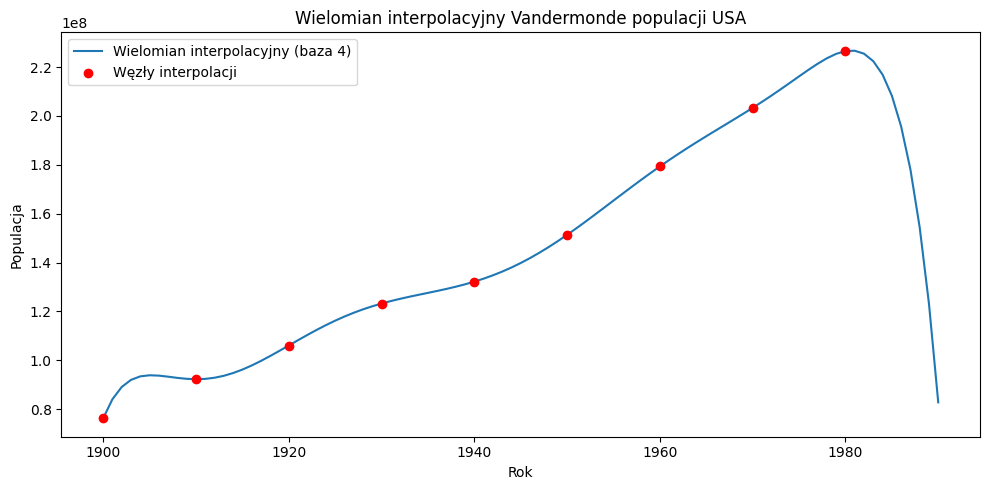

In [6]:
c4 = np.linalg.solve(V4, population.astype(float))
print("Współczynniki wielomianu (baza 4):")
print(c4)

def horner_basis4(t_eval, c, center=1940, scale=40):
    x = (t_eval - center) / scale
    result = np.zeros_like(t_eval, dtype=float)
    for coeff in reversed(c):
        result = result * x + coeff
    return result

t_plot = np.arange(1900, 1991, 1, dtype=float)
p_plot = horner_basis4(t_plot, c4)

plt.figure(figsize=(10, 5))
plt.plot(t_plot, p_plot, label='Wielomian interpolacyjny (baza 4)')
plt.scatter(years, population, color='red', zorder=5, label='Węzły interpolacji')
plt.xlabel('Rok')
plt.ylabel('Populacja')
plt.title('Wielomian interpolacyjny Vandermonde populacji USA')
plt.legend()
plt.tight_layout()
plt.show()

### (d) Ekstrapolacja do roku 1990

In [7]:
true_1990 = 248709873
pred_1990 = horner_basis4(np.array([1990.0]), c4)[0]
rel_error = abs(pred_1990 - true_1990) / true_1990

print(f"Wartość prawdziwa (1990):  {true_1990}")
print(f"Wartość przewidywana:      {pred_1990:.0f}")
print(f"Błąd względny:             {rel_error:.6f} ({rel_error*100:.4f}%)")

Wartość prawdziwa (1990):  248709873
Wartość przewidywana:      82749141
Błąd względny:             0.667286 (66.7286%)


### (e) Wielomian interpolacyjny Lagrange'a

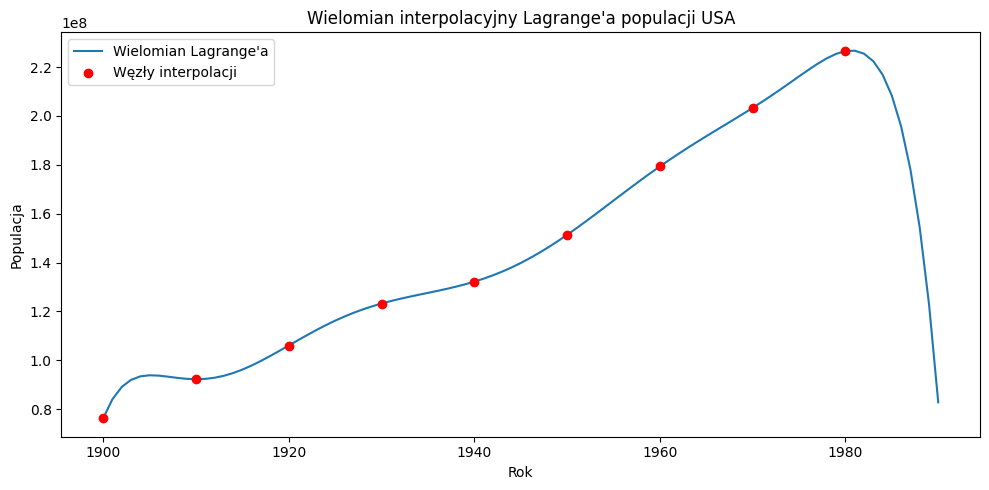

In [8]:
def lagrange_interpolate(t_nodes, y_nodes, t_eval):
    n_nodes = len(t_nodes)
    result = np.zeros_like(t_eval, dtype=float)
    for i in range(n_nodes):
        Li = np.ones_like(t_eval, dtype=float)
        for j in range(n_nodes):
            if j != i:
                Li *= (t_eval - t_nodes[j]) / (t_nodes[i] - t_nodes[j])
        result += y_nodes[i] * Li
    return result

p_lagrange = lagrange_interpolate(years.astype(float), population.astype(float), t_plot)

plt.figure(figsize=(10, 5))
plt.plot(t_plot, p_lagrange, label='Wielomian Lagrange\'a')
plt.scatter(years, population, color='red', zorder=5, label='Węzły interpolacji')
plt.xlabel('Rok')
plt.ylabel('Populacja')
plt.title('Wielomian interpolacyjny Lagrange\'a populacji USA')
plt.legend()
plt.tight_layout()
plt.show()

### (f) Wielomian interpolacyjny Newtona (iloraz różnicowy)

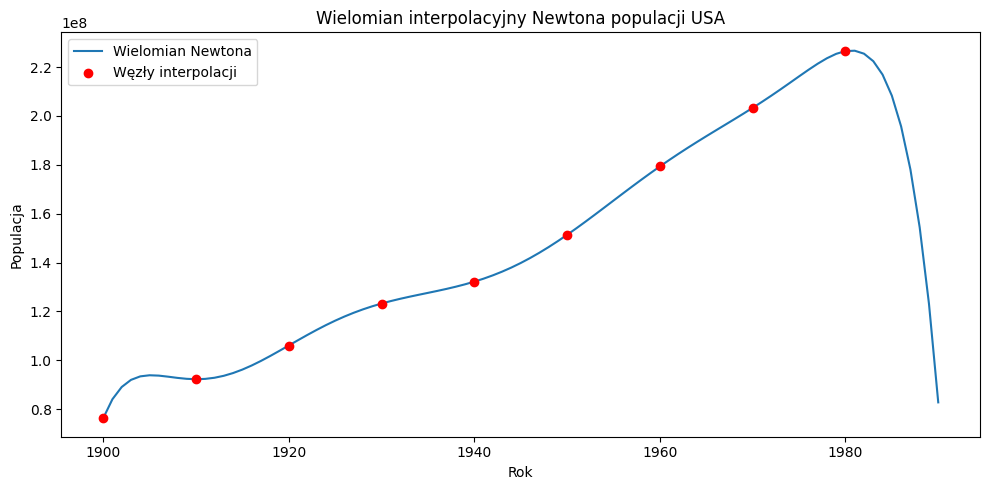

In [9]:
def divided_differences(t_nodes, y_nodes):
    n_nodes = len(t_nodes)
    dd = y_nodes.astype(float).copy()
    coeff = [dd[0]]
    for k in range(1, n_nodes):
        dd[k:] = (dd[k:] - dd[k-1:-1]) / (t_nodes[k:] - t_nodes[:n_nodes-k])
        coeff.append(dd[k])
    return np.array(coeff)

def newton_interpolate(t_nodes, coeff, t_eval):
    n_nodes = len(t_nodes)
    result = coeff[-1] * np.ones_like(t_eval, dtype=float)
    for k in range(n_nodes - 2, -1, -1):
        result = result * (t_eval - t_nodes[k]) + coeff[k]
    return result

t_nodes_f = years.astype(float)
newton_coeffs = divided_differences(t_nodes_f, population.astype(float))
p_newton = newton_interpolate(t_nodes_f, newton_coeffs, t_plot)

plt.figure(figsize=(10, 5))
plt.plot(t_plot, p_newton, label='Wielomian Newtona')
plt.scatter(years, population, color='red', zorder=5, label='Węzły interpolacji')
plt.xlabel('Rok')
plt.ylabel('Populacja')
plt.title('Wielomian interpolacyjny Newtona populacji USA')
plt.legend()
plt.tight_layout()
plt.show()

### (g) Dane zaokrąglone do jednego miliona – wpływ na współczynniki i ekstrapolację

In [10]:
# Zaokrąglenie danych do najbliższego miliona
population_rounded = np.round(population / 1e6) * 1e6

print("Oryginalne dane:")
for y, p in zip(years, population):
    print(f"  {y}: {p}")
print("\nDane zaokrąglone do 1 miliona:")
for y, p in zip(years, population_rounded):
    print(f"  {y}: {p:.0f}")

# Wyznaczamy nowe współczynniki (baza 4 – najlepiej uwarunkowana)
c4_rounded = np.linalg.solve(V4, population_rounded)

print("\nPorównanie współczynników (baza 4):")
print(f"{'j':>3}  {'oryginalne':>20}  {'zaokrąglone':>20}")
for j, (co, cr) in enumerate(zip(c4, c4_rounded)):
    print(f"  {j}  {co:20.4f}  {cr:20.4f}")

# Ekstrapolacja do roku 1990 z zaokrąglonymi danymi
pred_1990_rounded = horner_basis4(np.array([1990.0]), c4_rounded)[0]
rel_error_rounded = abs(pred_1990_rounded - true_1990) / true_1990

print(f"\nEkstrapolacja 1990 (zaokrąglone):  {pred_1990_rounded:.0f}")
print(f"Błąd względny (zaokrąglone):        {rel_error_rounded:.6f} ({rel_error_rounded*100:.4f}%)")
print(f"Błąd względny (oryginalne):         {rel_error:.6f} ({rel_error*100:.4f}%)")

Oryginalne dane:
  1900: 76212168
  1910: 92228496
  1920: 106021537
  1930: 123202624
  1940: 132164569
  1950: 151325798
  1960: 179323175
  1970: 203302031
  1980: 226542199

Dane zaokrąglone do 1 miliona:
  1900: 76000000
  1910: 92000000
  1920: 106000000
  1930: 123000000
  1940: 132000000
  1950: 151000000
  1960: 179000000
  1970: 203000000
  1980: 227000000

Porównanie współczynników (baza 4):
  j            oryginalne           zaokrąglone
  0        132164569.0000        132000000.0000
  1         46130765.5762         45957142.8571
  2        102716314.7857        100141269.8413
  3        182527130.1778        181111111.1111
  4       -374614714.8889       -356755555.5556
  5       -342668455.8222       -338488888.8889
  6        606291249.7778        570311111.1111
  7        189175575.5683        186920634.9206
  8       -315180235.1746       -294196825.3968

Ekstrapolacja 1990 (zaokrąglone):  109000000
Błąd względny (zaokrąglone):        0.561738 (56.1738%)
Błąd względn

## Zadanie 2 – Funkcje sklejane i wielomian Lagrange'a dla produkcji cytrusów

In [11]:
# Dane z zadania (produkcja w jednostkach 10^5 kg)
years2 = np.array([1965, 1970, 1980, 1985, 1990, 1991], dtype=float)
production = np.array([17769, 24001, 25961, 34336, 29036, 33417], dtype=float)

# Punkty do estymacji i wartości prawdziwe
query_years = np.array([1962, 1977, 1992], dtype=float)
true_values = np.array([12380, 27403, 32059], dtype=float)

### Kubiczne funkcje sklejane – różne warunki brzegowe

In [12]:
# 1. Natural spline (natural): f''(x0) = f''(xn) = 0
cs_natural = CubicSpline(years2, production, bc_type='natural')
pred_natural = cs_natural(query_years)

# 2. Not-a-knot spline: trzecia pochodna ciągła na pierwszym i ostatnim węźle wewnętrznym
cs_nak = CubicSpline(years2, production, bc_type='not-a-knot')
pred_nak = cs_nak(query_years)

# 3. Clamped spline (warunki pochodnej pierwszej = 0 na obu końcach)
cs_clamped = CubicSpline(years2, production, bc_type=((1, 0.0), (1, 0.0)))
pred_clamped = cs_clamped(query_years)

pchi = PchipInterpolator(years2,production)


print("Estymacje produkcji cytrusów za pomocą kubicznych funkcji sklejanych:")
print(f"{'Rok':>5}  {'Prawdziwa':>10}  {'Natural':>10}  {'Not-a-knot':>12}  {'Clamped':>10}")
for i in range(len(query_years)):
    print(f"{int(query_years[i]):>5}  {true_values[i]:>10.0f}  {pred_natural[i]:>10.1f}  {pred_nak[i]:>12.1f}  {pred_clamped[i]:>10.1f}")

print("\nBłędy względne:")
print(f"{'Rok':>5}  {'Natural':>10}  {'Not-a-knot':>12}  {'Clamped':>10}")
for i in range(len(query_years)):
    e_nat = abs(pred_natural[i] - true_values[i]) / true_values[i]
    e_nak = abs(pred_nak[i] - true_values[i]) / true_values[i]
    e_cl  = abs(pred_clamped[i] - true_values[i]) / true_values[i]
    print(f"{int(query_years[i]):>5}  {e_nat:>10.4f}  {e_nak:>12.4f}  {e_cl:>10.4f}")

Estymacje produkcji cytrusów za pomocą kubicznych funkcji sklejanych:
  Rok   Prawdziwa     Natural    Not-a-knot     Clamped
 1962       12380     13285.3        5146.1     24313.0
 1977       27403     22934.2       22641.8     23126.0
 1992       32059     37798.0       41894.4     22165.8

Błędy względne:
  Rok     Natural    Not-a-knot     Clamped
 1962      0.0731        0.5843      0.9639
 1977      0.1631        0.1737      0.1561
 1992      0.1790        0.3068      0.3086


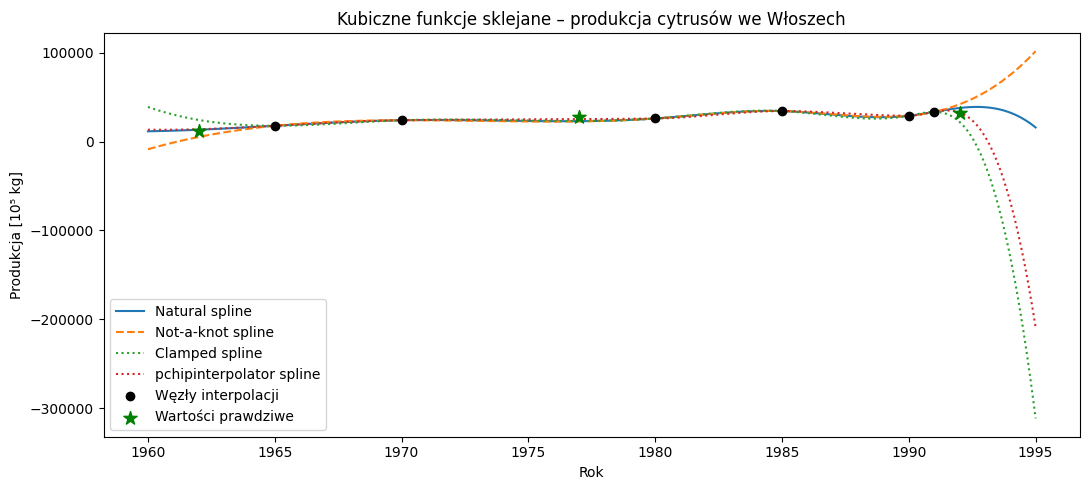

In [13]:
# Wykres funkcji sklejanych
t_fine = np.linspace(1960, 1995, 500)

plt.figure(figsize=(11, 5))
plt.plot(t_fine, cs_natural(t_fine), label='Natural spline', linewidth=1.5)
plt.plot(t_fine, cs_nak(t_fine), label='Not-a-knot spline', linewidth=1.5, linestyle='--')
plt.plot(t_fine, cs_clamped(t_fine), label='Clamped spline', linewidth=1.5, linestyle=':')
plt.plot(t_fine, pchi(t_fine), label='pchipinterpolator spline', linewidth=1.5, linestyle=':')
plt.scatter(years2, production, color='black', zorder=5, label='Węzły interpolacji')
plt.scatter(query_years, true_values, color='green', marker='*', s=100, zorder=5, label='Wartości prawdziwe')
plt.xlabel('Rok')
plt.ylabel('Produkcja [10⁵ kg]')
plt.title('Kubiczne funkcje sklejane – produkcja cytrusów we Włoszech')
plt.legend()
plt.tight_layout()
plt.show()

### Wielomian interpolacyjny Lagrange'a dla danych o cytrusach

Estymacje wielomianem Lagrange'a:
  Rok   Prawdziwa    Lagrange    Błąd wzgl.
 1962       12380    -77765.4        7.2815
 1977       27403     15405.0        0.4378
 1992       32059     43127.2        0.3452


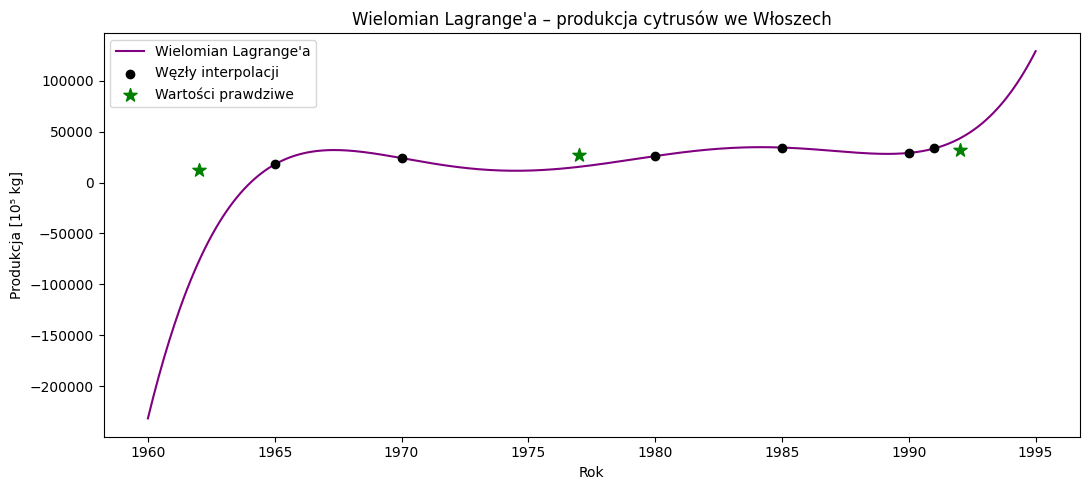

In [14]:
pred_lagrange2 = lagrange_interpolate(years2, production, query_years)

print("Estymacje wielomianem Lagrange'a:")
print(f"{'Rok':>5}  {'Prawdziwa':>10}  {'Lagrange':>10}  {'Błąd wzgl.':>12}")
for i in range(len(query_years)):
    e = abs(pred_lagrange2[i] - true_values[i]) / true_values[i]
    print(f"{int(query_years[i]):>5}  {true_values[i]:>10.0f}  {pred_lagrange2[i]:>10.1f}  {e:>12.4f}")

# Wykres z Lagrange'em
p_lagrange2_fine = lagrange_interpolate(years2, production, t_fine)

plt.figure(figsize=(11, 5))
plt.plot(t_fine, p_lagrange2_fine, label="Wielomian Lagrange'a", linewidth=1.5, color='purple')
plt.scatter(years2, production, color='black', zorder=5, label='Węzły interpolacji')
plt.scatter(query_years, true_values, color='green', marker='*', s=100, zorder=5, label='Wartości prawdziwe')
plt.xlabel('Rok')
plt.ylabel('Produkcja [10⁵ kg]')
plt.title("Wielomian Lagrange'a – produkcja cytrusów we Włoszech")
plt.legend()
plt.tight_layout()
plt.show()

### Porównanie metod

In [15]:
print("Podsumowanie – błędy względne dla wszystkich metod:")
print(f"{'Rok':>5}  {'Natural':>10}  {'Not-a-knot':>12}  {'Clamped':>10}  {'Lagrange':>10}")
for i in range(len(query_years)):
    e_nat = abs(pred_natural[i] - true_values[i]) / true_values[i]
    e_nak = abs(pred_nak[i] - true_values[i]) / true_values[i]
    e_cl  = abs(pred_clamped[i] - true_values[i]) / true_values[i]
    e_lag = abs(pred_lagrange2[i] - true_values[i]) / true_values[i]
    print(f"{int(query_years[i]):>5}  {e_nat:>10.4f}  {e_nak:>12.4f}  {e_cl:>10.4f}  {e_lag:>10.4f}")

Podsumowanie – błędy względne dla wszystkich metod:
  Rok     Natural    Not-a-knot     Clamped    Lagrange
 1962      0.0731        0.5843      0.9639      7.2815
 1977      0.1631        0.1737      0.1561      0.4378
 1992      0.1790        0.3068      0.3086      0.3452
